# Advanced Cepstral Feature Families

This notebook compares the feature families exposed by the Python extension beyond the introductory MFCC/GFCC examples: IMFCC, LFCC, BFCC, MSRCC, NGCC, PSRCC, PNCC, LPCC, PLP, RPLP, and CQCC.


> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
import math

import matplotlib.pyplot as plt
import spafe

In [2]:
fs = 16_000
seconds = 1.0
signal = [
    0.7 * math.sin(2.0 * math.pi * 220.0 * n / fs)
    + 0.3 * math.sin(2.0 * math.pi * 660.0 * n / fs)
    for n in range(int(fs * seconds))
]

opts = spafe.FeatureOptions(
    fs=fs,
    nfft=256,
    nfilts=24,
    num_ceps=13,
    win_hop=0.02,
    normalize="mean_subtraction",
    lifter=-22,
)
cqcc_opts = spafe.CqccOptions(number_of_octaves=5, number_of_bins_per_octave=12)
print(f"samples={len(signal)}")

samples=16000


In [3]:
feature_sets = {
    "MFCC": spafe.mfcc(signal, opts),
    "IMFCC": spafe.imfcc(signal, opts),
    "LFCC": spafe.lfcc(signal, opts),
    "BFCC": spafe.bfcc(signal, opts),
    "MSRCC": spafe.msrcc(signal, opts, gamma=-1.0 / 7.0),
    "NGCC": spafe.ngcc(signal, opts),
    "PSRCC": spafe.psrcc(signal, opts, gamma=-1.0 / 7.0),
    "PNCC": spafe.pncc(signal, opts, power=2.0),
    "LPCC": spafe.lpcc(signal, opts),
    "PLP": spafe.plp(signal, opts, do_rasta=False),
    "RPLP": spafe.rplp(signal, opts),
    "CQCC": spafe.cqcc(signal, opts, cqcc_opts),
}
{name: (len(matrix), len(matrix[0])) for name, matrix in feature_sets.items()}

{'MFCC': (49, 13),
 'IMFCC': (49, 13),
 'LFCC': (49, 13),
 'BFCC': (49, 13),
 'MSRCC': (49, 13),
 'NGCC': (49, 13),
 'PSRCC': (49, 13),
 'PNCC': (49, 13),
 'LPCC': (49, 13),
 'PLP': (49, 13),
 'RPLP': (49, 13),
 'CQCC': (49, 13)}

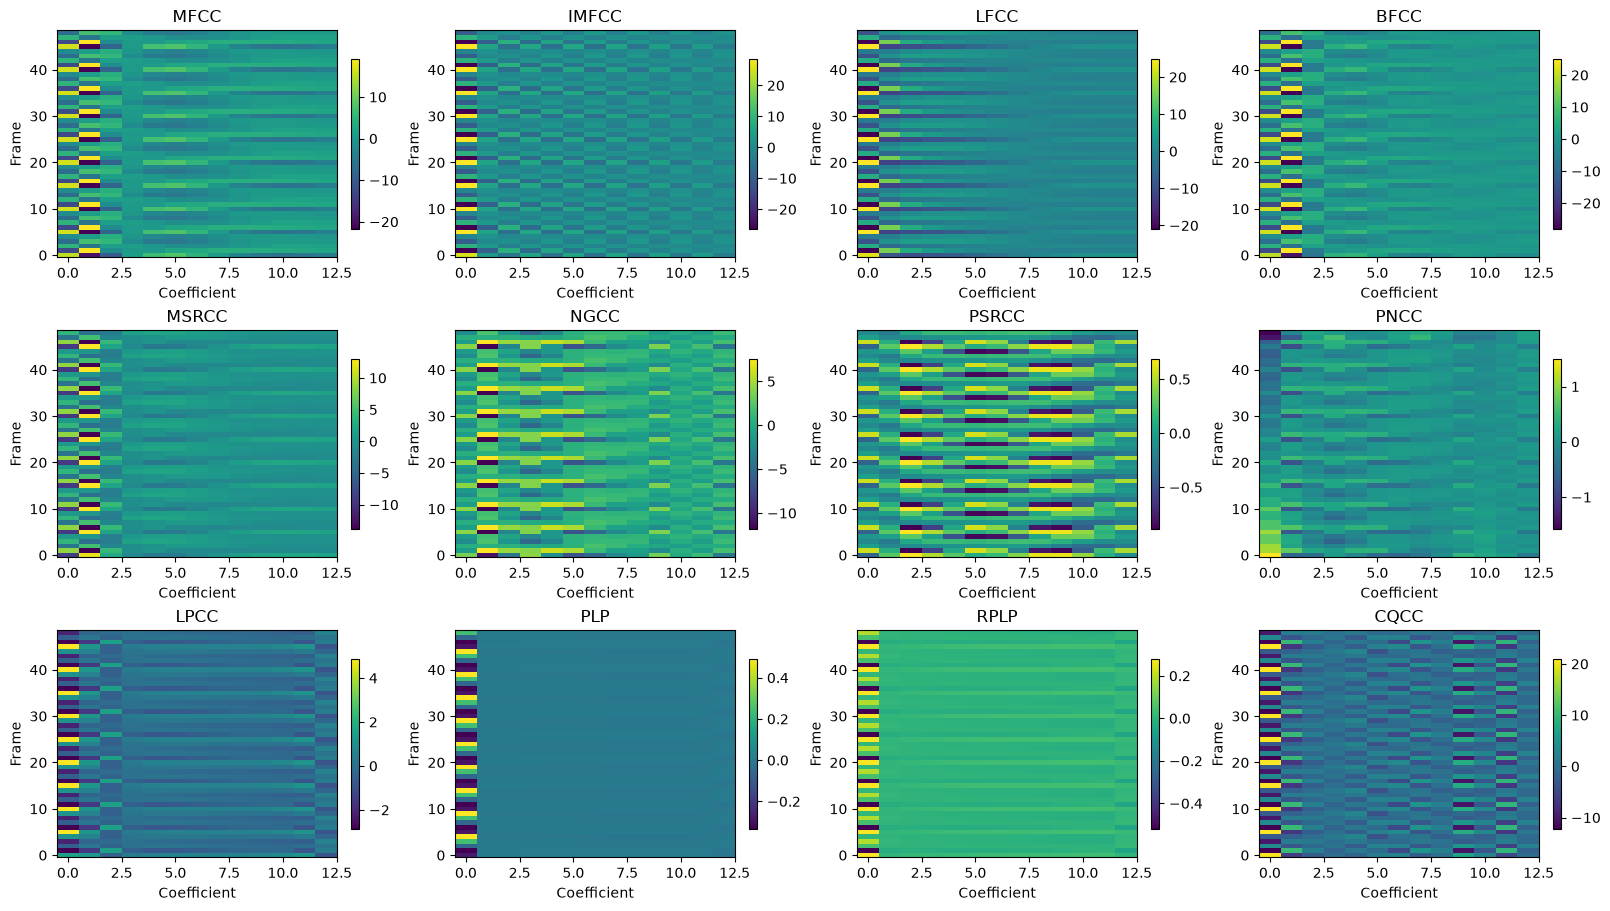

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9), constrained_layout=True)
for ax, (name, matrix) in zip(axes.ravel(), feature_sets.items()):
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Frame")
    fig.colorbar(image, ax=ax, shrink=0.75)
plt.show()

In [5]:
first_coefficients = {name: matrix[0][:5] for name, matrix in feature_sets.items()}
for name, values in first_coefficients.items():
    print(f"{name:5s}", [round(value, 3) for value in values])

MFCC  [15.268, -19.806, -9.857, 1.176, 6.518]
IMFCC [25.276, 3.387, -4.884, 5.743, -6.079]
LFCC  [22.742, -8.892, -10.15, -8.876, -7.455]
BFCC  [19.749, -25.366, -7.949, 6.169, 6.811]
MSRCC [-8.856, 12.07, 2.577, -1.32, -2.709]
NGCC  [3.522, -10.913, -4.176, 4.2, -2.207]
PSRCC [-0.373, 0.28, 0.683, 0.504, 0.279]
PNCC  [1.502, -0.591, -0.484, 0.104, -0.176]
LPCC  [1.542, 1.27, -0.501, 0.311, 0.541]
PLP   [-0.276, 0.003, 0.002, 0.003, 0.004]
RPLP  [0.28, 0.006, 0.011, 0.017, 0.022]
CQCC  [20.613, -6.386, -2.468, -0.422, -1.489]
